In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
from Leiden_analyze import Leidenanalyzer
from umap_Azimuth_celltype import AZIMUTHvisualizer
import scanpy as sc
import pandas as pd

/staging/biology/jane0528/miniconda3/envs/scrublet_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
#載入Harmony+Azimuth後的Adata
adata_merged=sc.read_h5ad('/staging/biology/jane0528/NMOSD/scRNA/Dataset/My_merged_protein_coding_genes/Adata/My_merged_Azimuth(protein_coding).h5ad')
#載入我的已分群Adata
adata_clustered=sc.read_h5ad('/staging/biology/jane0528/NMOSD/scRNA/Dataset/My_merged_protein_coding_genes/Adata/Leiden_all_results(Harmony_nn_25_res_0.6).h5ad')

In [12]:
import numpy as np
adata_merged.obs["Condition"] = np.where(
    adata_merged.obs["orig.ident"].astype(str).str.startswith("nmo"),
    "NMOSD",
    "Control"
)

In [13]:
adata_predicted=adata_merged.copy()

In [14]:
#parameters
cluster_key = "leiden_nn25_res0.6" #原始分群label
label_key = "predicted.celltype.l2" #scVANI預測的結果
n_neighbors=25
ndim_pca=50

#把"predicted_label"加入leiden分群好的adata中
adata_predicted.obs[cluster_key]=adata_clustered.obs[cluster_key]

In [15]:
adata_predicted.obs

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,predicted.celltype.l1.score,predicted.celltype.l1,predicted.celltype.l2.score,predicted.celltype.l2,predicted.celltype.l3.score,predicted.celltype.l3,mapping.score,Condition,leiden_nn25_res0.6
nmo008_ACACTGACAATGAAAC-1,nmo008,11860.0,2988,3.971332,0.685193,CD4 T,0.624930,CD4 TCM,0.479567,CD4 TCM_1,0.160075,NMOSD,3
nmo008_AAGCCGCGTCGAAAGC-1,nmo008,11752.0,2838,3.556841,1.000000,CD4 T,1.000000,CD4 TCM,0.987932,CD4 TCM_2,0.821969,NMOSD,3
nmo008_TCAGATGGTCAACTGT-1,nmo008,11642.0,3070,3.848136,1.000000,CD4 T,1.000000,CD4 TCM,0.992778,CD4 TCM_2,0.949871,NMOSD,3
nmo008_CTAACTTGTTAAAGTG-1,nmo008,10934.0,3116,5.341138,1.000000,CD4 T,1.000000,CD4 TCM,1.000000,CD4 TCM_2,0.907426,NMOSD,3
nmo008_AGAGCTTAGAGTAAGG-1,nmo008,10910.0,3136,6.186984,0.852914,CD8 T,0.852914,CD8 TEM,0.469027,CD8 TEM_1,0.324083,NMOSD,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Control3_TTTGTCACACGGACAA-1,Control3,4684.0,1876,2.625961,0.961912,other T,0.898177,MAIT,0.898177,MAIT,0.824499,Control,9
Control3_TTTGTCACAGCAGTTT-1,Control3,2438.0,1224,1.886792,0.902620,CD8 T,0.886428,CD8 TEM,0.758866,CD8 TEM_2,0.558437,Control,1
Control3_TTTGTCAGTCTTCAAG-1,Control3,2902.0,1424,1.654032,1.000000,NK,1.000000,NK,1.000000,NK_2,0.811304,Control,2
Control3_TTTGTCATCAATCACG-1,Control3,3851.0,1240,1.843677,0.967224,CD4 T,0.909714,CD4 TCM,0.909714,CD4 TCM_1,0.856634,Control,0


In [16]:
celltype1_df=pd.read_csv("/staging/biology/jane0528/NMOSD/scRNA/Dataset/My_merged_protein_coding_genes_V2/Harmony_Azimuth_celltype_composition/Harmony50/leiden_nn25_res0.6_predicted.celltype.l1.csv")
celltype1_df_v1=celltype1_df.loc[:,['leiden_nn25_res0.6','Dominant_celltype']]
celltype1_df_v1.rename(columns={"Dominant_celltype":"Major_celltype"}, inplace=True)

In [17]:
obs = adata_predicted.obs.copy()
obs["cell_id"] = obs.index  # 存 row names

obs["leiden_nn25_res0.6"] = obs["leiden_nn25_res0.6"].astype(int)
celltype1_df_v1["leiden_nn25_res0.6"] = celltype1_df_v1["leiden_nn25_res0.6"].astype(int)

obs = obs.merge(celltype1_df_v1, on="leiden_nn25_res0.6", how="left")
obs = obs.set_index("cell_id")  # 還原 row names

adata_predicted.obs = obs

In [18]:
# Major celltyps 分別建 adata
adata_Mono_DC =  adata_predicted[
    adata_predicted.obs["Major_celltype"].isin(["DC", "Mono"])
].copy()

adata_T =  adata_predicted[
    adata_predicted.obs["Major_celltype"].isin(["other T","CD4 T","CD8 T"])
].copy()

adata_B =  adata_predicted[
    adata_predicted.obs["Major_celltype"].isin(["B"])
].copy()

adata_NK =  adata_predicted[
    adata_predicted.obs["Major_celltype"].isin(["NK"])
].copy()

In [19]:
adata_Mono_DC.obs

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,predicted.celltype.l1.score,predicted.celltype.l1,predicted.celltype.l2.score,predicted.celltype.l2,predicted.celltype.l3.score,predicted.celltype.l3,mapping.score,Condition,leiden_nn25_res0.6,Major_celltype
cell_id,,,,,,,,,,,,,,
nmo001_CGTAGCGAGTGAACGC-1,nmo001,7221.0,2477,1.758759,0.956949,CD8 T,0.944669,CD8 TEM,0.914576,CD8 TEM_2,0.416265,NMOSD,4,Mono
nmo001_CAGTAACCACTGTGTA-1,nmo001,5762.0,2159,5.189170,0.972932,CD4 T,0.922977,CD4 TCM,0.581656,CD4 TCM_1,0.508060,NMOSD,14,DC
nmo003_GATCGCGAGGCTACGA-1,nmo003,7561.0,1681,1.269673,0.454518,CD8 T,0.454518,CD8 TEM,0.350263,CD8 TEM_2,1.000000,NMOSD,14,DC
nmo003_CCTCTGATCCGCAGTG-1,nmo003,5666.0,2208,4.306389,0.783510,CD4 T,0.779078,CD4 TCM,0.779078,CD4 TCM_1,0.117328,NMOSD,14,DC
nmo003_GTTAAGCTCTGTGCAA-1,nmo003,1244.0,472,0.080386,1.000000,B,1.000000,Plasmablast,0.729011,Plasma,0.981469,NMOSD,14,DC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Control3_TTTGGTTTCGCTAGCG-1,Control3,1909.0,1193,2.095338,1.000000,Mono,1.000000,CD14 Mono,1.000000,CD14 Mono,0.600607,Control,4,Mono
Control3_TTTGGTTTCGGAATCT-1,Control3,6697.0,2567,1.060176,1.000000,Mono,1.000000,CD14 Mono,1.000000,CD14 Mono,0.699096,Control,4,Mono
Control3_TTTGGTTTCTGCTTGC-1,Control3,2543.0,1203,1.219033,1.000000,Mono,1.000000,CD14 Mono,1.000000,CD14 Mono,0.751123,Control,4,Mono


In [20]:
# col = "predicted.celltype.l2"

# counts = adata_NK.obs[col].value_counts(dropna=False)
# props  = adata_NK.obs[col].value_counts(normalize=True, dropna=False)

# ratio_df = (
#     counts.to_frame("n")
#     .join((props*100).to_frame("percent"))
#     .sort_values("n", ascending=False)
# )

# ratio_df


In [21]:
lda = Leidenanalyzer(adata_Mono_DC, ndim_pca=50,use_rep='X_harmony', base_output="../Dataset/My_merged_Celltype2_Reclustered_TEST")

#adata_T = lda.perform_leiden_modularity(nn_list=[10,15,20,25,30,35,40])


In [22]:
# #n=20
# neighbor=30
# adata_B = lda.find_best_resolution(best_nn=neighbor, resolutions=[0.6,0.8,1.0,1.2,1.4,1.6,1.8,2.0])


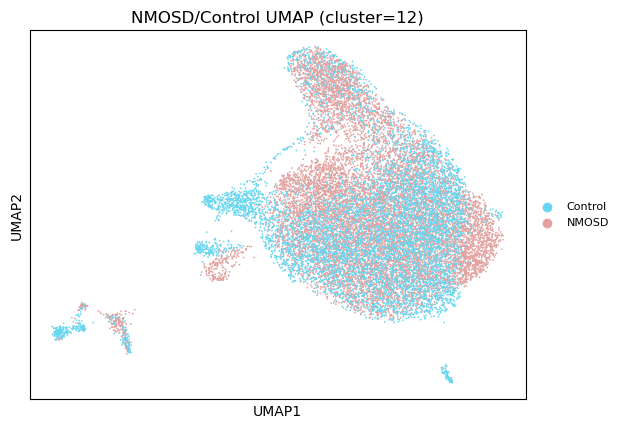

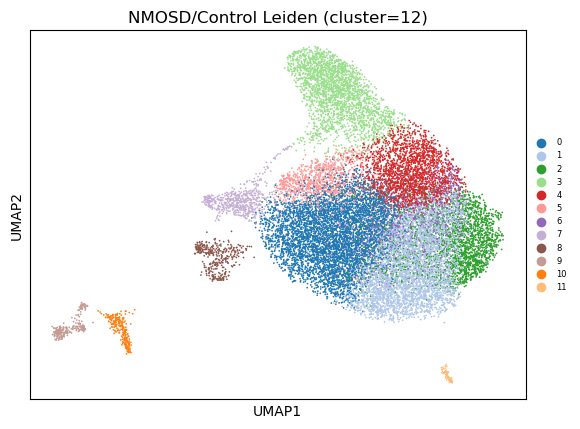

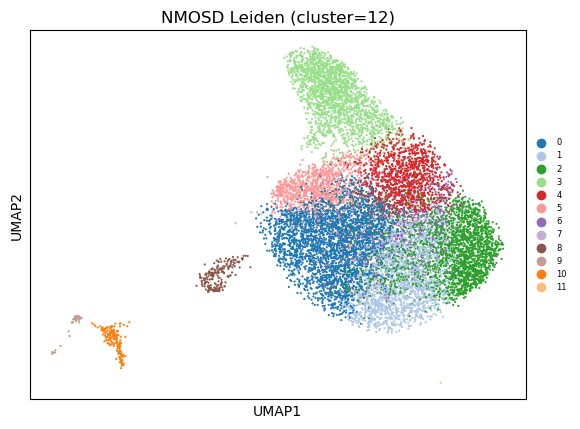

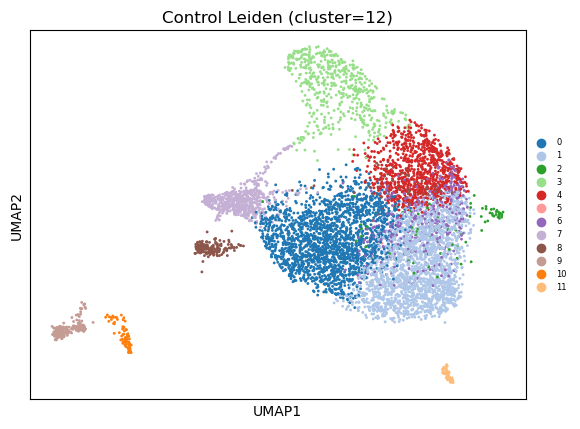

Leiden_nn20_res0.6 UMAP all plots saved done !


In [23]:
#----{設定最佳參數組合}
neighbor=20
best_cluster_number = 12
best_res=0.6
adata_Mono_DC= lda.plot_leiden_umap(best_nn=neighbor, best_res=best_res, best_cluster_number=best_cluster_number)

In [24]:
adata_Mono_DC.obs.loc[:,['leiden_nn20_res0.6','cluster']]
adata_Mono_DC.obs.drop(columns='leiden_nn20_res0.6',inplace=True)
adata_Mono_DC.obs.rename(columns={'cluster':'Mono_DC_cluster'},inplace=True)

In [25]:
adata_Mono_DC.obs

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,predicted.celltype.l1.score,predicted.celltype.l1,predicted.celltype.l2.score,predicted.celltype.l2,predicted.celltype.l3.score,predicted.celltype.l3,mapping.score,Condition,leiden_nn25_res0.6,Major_celltype,Mono_DC_cluster
cell_id,,,,,,,,,,,,,,,
nmo001_CGTAGCGAGTGAACGC-1,nmo001,7221.0,2477,1.758759,0.956949,CD8 T,0.944669,CD8 TEM,0.914576,CD8 TEM_2,0.416265,NMOSD,4,Mono,5
nmo001_CAGTAACCACTGTGTA-1,nmo001,5762.0,2159,5.189170,0.972932,CD4 T,0.922977,CD4 TCM,0.581656,CD4 TCM_1,0.508060,NMOSD,14,DC,9
nmo003_GATCGCGAGGCTACGA-1,nmo003,7561.0,1681,1.269673,0.454518,CD8 T,0.454518,CD8 TEM,0.350263,CD8 TEM_2,1.000000,NMOSD,14,DC,10
nmo003_CCTCTGATCCGCAGTG-1,nmo003,5666.0,2208,4.306389,0.783510,CD4 T,0.779078,CD4 TCM,0.779078,CD4 TCM_1,0.117328,NMOSD,14,DC,9
nmo003_GTTAAGCTCTGTGCAA-1,nmo003,1244.0,472,0.080386,1.000000,B,1.000000,Plasmablast,0.729011,Plasma,0.981469,NMOSD,14,DC,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Control3_TTTGGTTTCGCTAGCG-1,Control3,1909.0,1193,2.095338,1.000000,Mono,1.000000,CD14 Mono,1.000000,CD14 Mono,0.600607,Control,4,Mono,0
Control3_TTTGGTTTCGGAATCT-1,Control3,6697.0,2567,1.060176,1.000000,Mono,1.000000,CD14 Mono,1.000000,CD14 Mono,0.699096,Control,4,Mono,1
Control3_TTTGGTTTCTGCTTGC-1,Control3,2543.0,1203,1.219033,1.000000,Mono,1.000000,CD14 Mono,1.000000,CD14 Mono,0.751123,Control,4,Mono,0


In [26]:
#parameters
cluster_key = "Mono_DC_cluster" #原始分群label
label_key = "predicted.celltype.l2" #scVANI預測的結果
n_neighbors=20
ndim_pca=50

In [27]:
adata_Mono_DC.obs

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,predicted.celltype.l1.score,predicted.celltype.l1,predicted.celltype.l2.score,predicted.celltype.l2,predicted.celltype.l3.score,predicted.celltype.l3,mapping.score,Condition,leiden_nn25_res0.6,Major_celltype,Mono_DC_cluster
cell_id,,,,,,,,,,,,,,,
nmo001_CGTAGCGAGTGAACGC-1,nmo001,7221.0,2477,1.758759,0.956949,CD8 T,0.944669,CD8 TEM,0.914576,CD8 TEM_2,0.416265,NMOSD,4,Mono,5
nmo001_CAGTAACCACTGTGTA-1,nmo001,5762.0,2159,5.189170,0.972932,CD4 T,0.922977,CD4 TCM,0.581656,CD4 TCM_1,0.508060,NMOSD,14,DC,9
nmo003_GATCGCGAGGCTACGA-1,nmo003,7561.0,1681,1.269673,0.454518,CD8 T,0.454518,CD8 TEM,0.350263,CD8 TEM_2,1.000000,NMOSD,14,DC,10
nmo003_CCTCTGATCCGCAGTG-1,nmo003,5666.0,2208,4.306389,0.783510,CD4 T,0.779078,CD4 TCM,0.779078,CD4 TCM_1,0.117328,NMOSD,14,DC,9
nmo003_GTTAAGCTCTGTGCAA-1,nmo003,1244.0,472,0.080386,1.000000,B,1.000000,Plasmablast,0.729011,Plasma,0.981469,NMOSD,14,DC,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Control3_TTTGGTTTCGCTAGCG-1,Control3,1909.0,1193,2.095338,1.000000,Mono,1.000000,CD14 Mono,1.000000,CD14 Mono,0.600607,Control,4,Mono,0
Control3_TTTGGTTTCGGAATCT-1,Control3,6697.0,2567,1.060176,1.000000,Mono,1.000000,CD14 Mono,1.000000,CD14 Mono,0.699096,Control,4,Mono,1
Control3_TTTGGTTTCTGCTTGC-1,Control3,2543.0,1203,1.219033,1.000000,Mono,1.000000,CD14 Mono,1.000000,CD14 Mono,0.751123,Control,4,Mono,0


In [28]:
viz = AZIMUTHvisualizer(adata_Mono_DC, adata_Mono_DC,use_rep='X_harmony',ndim_pca=ndim_pca, base_output="../Dataset/My_merged_Celltype2_Reclustered_TEST")
viz.map_celltype(cluster_key, label_key)
viz.prepare_umap(n_neighbors=n_neighbors)
viz.plot_umap_and_composition(cluster_key,label_key)
viz.evaluate_clustering(cluster_key,label_key)

Mapped Mono_DC_cluster cell types done!
UMAP computed using 20 neighbors and 50 PCs.
All plots saved to: ../Dataset/My_merged_Celltype2_Reclustered_TEST/Harmony_Azimuth_plot/Harmony50/Mono_DC_cluster/predicted.celltype.l2
ARI: 0.1481, NMI: 0.3971, V-measure: 0.3971
ARI & NMI & Ｖ-measure evaluation points saved to: ../Dataset/My_merged_Celltype2_Reclustered_TEST/Harmony_Azimuth_evaluation/Harmony50/Mono_DC_cluster_predicted.celltype.l2.csv


,Evaluation Index,Score
0,ARI,0.148143
1,NMI,0.397120
2,V-measure,0.397120


In [29]:
adata_Mono_DC= viz.export_celltype_composition(cluster_key,label_key)

   Mono_DC_cluster Dominant_celltype  Percentage
0                0         CD14 Mono    0.994594
1                1         CD14 Mono    0.999745
2                2         CD14 Mono    0.998758
3                3         CD16 Mono    0.978342
4                4         CD14 Mono    0.917133
5                5         CD14 Mono    0.980565
6                6         CD14 Mono    0.998879
7                7         CD14 Mono    0.572108
8                8              cDC2    0.616302
9                9           CD4 TCM    0.456204
10              10               pDC    0.612903
11              11         CD14 Mono    0.922078
Cell-type composition saved to: ../Dataset/My_merged_Celltype2_Reclustered_TEST/Harmony_Azimuth_celltype_composition/Harmony50/Mono_DC_cluster_predicted.celltype.l2.csv


In [30]:
adata_Mono_DC.obs

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,predicted.celltype.l1.score,predicted.celltype.l1,predicted.celltype.l2.score,predicted.celltype.l2,predicted.celltype.l3.score,predicted.celltype.l3,mapping.score,Condition,leiden_nn25_res0.6,Major_celltype,Mono_DC_cluster,cluster_annotation
cell_id,,,,,,,,,,,,,,,,
nmo001_CGTAGCGAGTGAACGC-1,nmo001,7221.0,2477,1.758759,0.956949,CD8 T,0.944669,CD8 TEM,0.914576,CD8 TEM_2,0.416265,NMOSD,4,Mono,5,CD14 Mono
nmo001_CAGTAACCACTGTGTA-1,nmo001,5762.0,2159,5.189170,0.972932,CD4 T,0.922977,CD4 TCM,0.581656,CD4 TCM_1,0.508060,NMOSD,14,DC,9,CD4 TCM
nmo003_GATCGCGAGGCTACGA-1,nmo003,7561.0,1681,1.269673,0.454518,CD8 T,0.454518,CD8 TEM,0.350263,CD8 TEM_2,1.000000,NMOSD,14,DC,10,pDC
nmo003_CCTCTGATCCGCAGTG-1,nmo003,5666.0,2208,4.306389,0.783510,CD4 T,0.779078,CD4 TCM,0.779078,CD4 TCM_1,0.117328,NMOSD,14,DC,9,CD4 TCM
nmo003_GTTAAGCTCTGTGCAA-1,nmo003,1244.0,472,0.080386,1.000000,B,1.000000,Plasmablast,0.729011,Plasma,0.981469,NMOSD,14,DC,10,pDC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Control3_TTTGGTTTCGCTAGCG-1,Control3,1909.0,1193,2.095338,1.000000,Mono,1.000000,CD14 Mono,1.000000,CD14 Mono,0.600607,Control,4,Mono,0,CD14 Mono
Control3_TTTGGTTTCGGAATCT-1,Control3,6697.0,2567,1.060176,1.000000,Mono,1.000000,CD14 Mono,1.000000,CD14 Mono,0.699096,Control,4,Mono,1,CD14 Mono
Control3_TTTGGTTTCTGCTTGC-1,Control3,2543.0,1203,1.219033,1.000000,Mono,1.000000,CD14 Mono,1.000000,CD14 Mono,0.751123,Control,4,Mono,0,CD14 Mono


In [31]:
# cluster_9=adata_Mono_DC_n20.obs.loc[adata_Mono_DC_n20.obs['Mono_DC_cluster']=='9',['predicted.celltype.l2']]

In [32]:
# cluster_9.value_counts()

In [33]:
adata_Mono_DC.obs["cell_id"] = adata_Mono_DC.obs.index
adata_Mono_DC_result = adata_Mono_DC.obs[['cell_id','cluster_annotation']].copy()
adata_Mono_DC_result.rename(columns={"cluster_annotation":"Mono_DC_subtype"})

,cell_id,Mono_DC_subtype
cell_id,,
nmo001_CGTAGCGAGTGAACGC-1,nmo001_CGTAGCGAGTGAACGC-1,CD14 Mono
nmo001_CAGTAACCACTGTGTA-1,nmo001_CAGTAACCACTGTGTA-1,CD4 TCM
nmo003_GATCGCGAGGCTACGA-1,nmo003_GATCGCGAGGCTACGA-1,pDC
nmo003_CCTCTGATCCGCAGTG-1,nmo003_CCTCTGATCCGCAGTG-1,CD4 TCM
nmo003_GTTAAGCTCTGTGCAA-1,nmo003_GTTAAGCTCTGTGCAA-1,pDC
...,...,...
Control3_TTTGGTTTCGCTAGCG-1,Control3_TTTGGTTTCGCTAGCG-1,CD14 Mono
Control3_TTTGGTTTCGGAATCT-1,Control3_TTTGGTTTCGGAATCT-1,CD14 Mono
Control3_TTTGGTTTCTGCTTGC-1,Control3_TTTGGTTTCTGCTTGC-1,CD14 Mono


In [35]:
adata_Mono_DC_result.to_csv('/staging/biology/jane0528/NMOSD/scRNA/Dataset/My_merged_Celltype2_Reclustered_TEST/Mono_DC_subtype_nn20.csv', index=False)

In [ ]:
import pandas as pd

for major_celltype in ['B','NK','T','Mono_DC']:
    csv1 = f"/staging/biology/jane0528/NMOSD/scRNA/Dataset/My_merged_Celltype2_Reclustered_v1/Azimuth_subcelltype_result/{major_celltype}_subtype_nn30.csv"
    csv2 = f"/staging/biology/jane0528/NMOSD/scRNA/Dataset/My_merged_Celltype2_Reclustered_v1/Azimuth_subcelltype_result/{major_celltype}_subtype_nn20.csv"

    df1 = pd.read_csv(csv1)
    df2 = pd.read_csv(csv2)

    # 改cluster_annotation 欄位名
    df1 = df1[["cell_id", "cluster_annotation"]].rename(columns={"cluster_annotation": f"{major_celltype}_celltype_nn30"})
    df2 = df2[["cell_id", "cluster_annotation"]].rename(columns={"cluster_annotation": f"{major_celltype}_celltype_nn20"})

    # 以 cell_id 合併
    m = df1.merge(df2, on="cell_id", how="inner")

    # 相同celltype
    same_ratio = (m[f"{major_celltype}_celltype_nn30"] == m[f"{major_celltype}_celltype_nn20"]).mean()

    print(f"相同 {major_celltype} celltypes 比例: {same_ratio*100:.2f}%")


相同 B celltypes 比例: 86.46%
相同 NK celltypes 比例: 98.03%
相同 T celltypes 比例: 97.90%
相同 Mono_DC celltypes 比例: 97.74%


: 